In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Pandas loaded")


Pandas loaded


In [207]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [208]:
from pathlib import Path

current_directory = Path.cwd()

project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

figures_folder = project_root / "reports" / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

print("Figures folder:", figures_folder)

Figures folder: c:\Github\retail-financial-intelligence\reports\figures


In [209]:
file_path = "c:\\Github\\retail-financial-intelligence\\data\\raw\\online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [210]:
for sheet in excel_file.sheet_names:
    temp = pd.read_excel(file_path, sheet_name=sheet)
    print(sheet, temp.shape)

Year 2009-2010 (525461, 8)
Year 2010-2011 (541910, 8)


In [211]:
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [212]:
rows, columns = df.shape

display("Number of rows:", rows)
display("Number of columns:", columns)

'Number of rows:'

1067371

'Number of columns:'

8

In [213]:
raw_df = df.copy()

print("Original rows:", len(df))
print("Working copy rows:", len(raw_df))

Original rows: 1067371
Working copy rows: 1067371


In [214]:
raw_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [215]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [216]:
raw_df.rename(columns={"Customer ID": "CustomerID"}, inplace=True)

In [217]:
raw_df["Invoice"] = raw_df["Invoice"].astype("string")
raw_df["StockCode"] = raw_df["StockCode"].astype("string")
raw_df["CustomerID"] = raw_df["CustomerID"].astype("Int64")
raw_df["InvoiceDate"] = pd.to_datetime(raw_df["InvoiceDate"], errors="coerce")

In [218]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  string        
 1   StockCode    1067371 non-null  string        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   Int64         
 7   Country      1067371 non-null  str           
dtypes: Int64(1), datetime64[us](1), float64(1), int64(1), object(1), str(1), string(2)
memory usage: 91.1+ MB


In [219]:
raw_df["Revenue"] = raw_df["Quantity"] * raw_df["Price"]

In [220]:
daily_revenue = (
    raw_df.set_index("InvoiceDate")["Revenue"]
      .resample("D")
      .sum()
)

daily_revenue.head()


InvoiceDate
2009-12-01    53173.03
2009-12-02    62763.59
2009-12-03    68093.05
2009-12-04    40346.40
2009-12-05     9803.05
Freq: D, Name: Revenue, dtype: float64

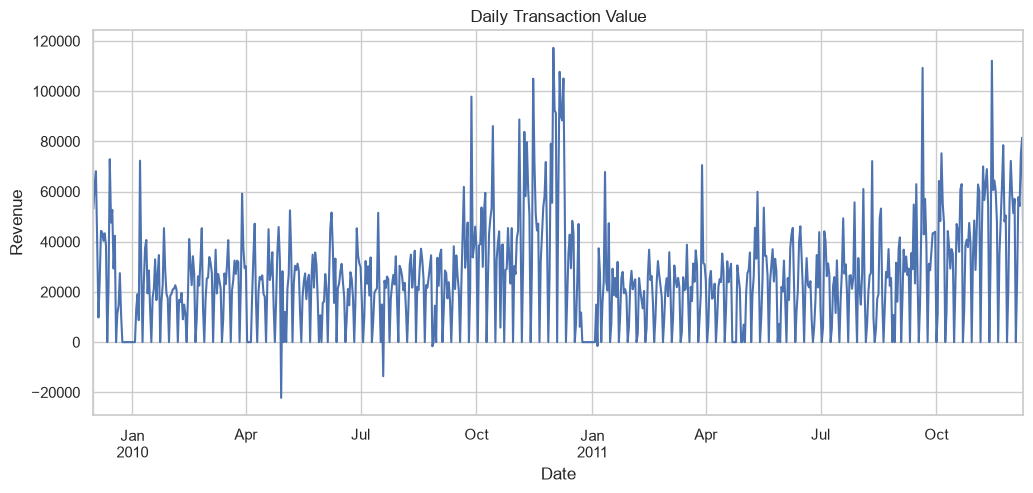

In [221]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

daily_revenue.plot()

plt.title("Daily Transaction Value")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

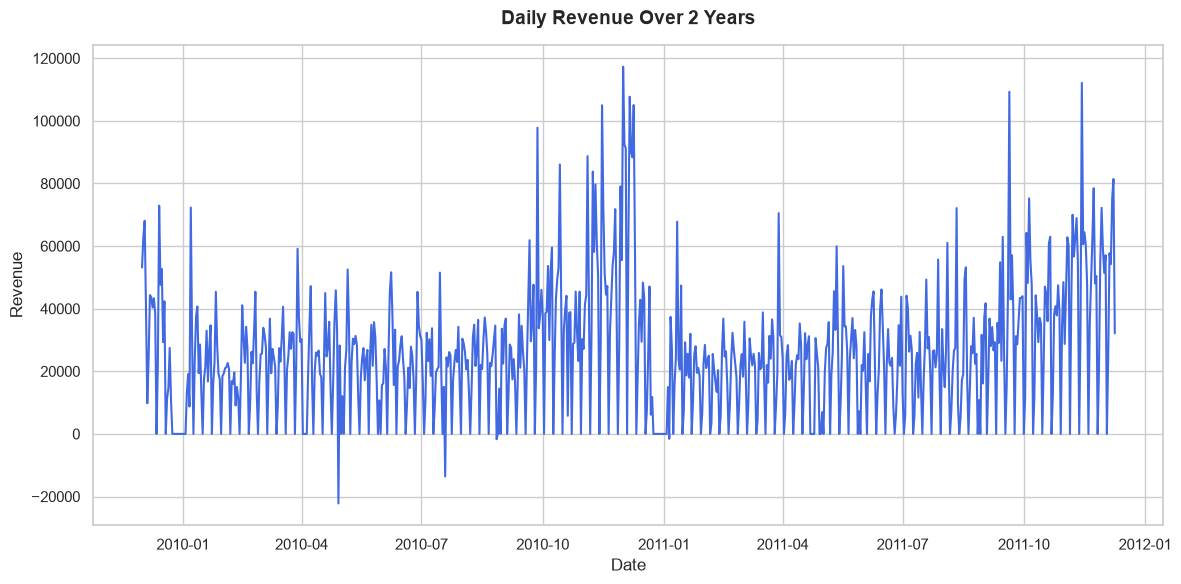

In [222]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(daily_revenue.index, daily_revenue.values, color="royalblue", linewidth=1.5)

# Add titles and labels
plt.title("Daily Revenue Over 2 Years", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Clean up layout and display
plt.tight_layout()
plt.show()

In [223]:
duplicates_before = raw_df.duplicated().value_counts()
print("Duplicate rows:", duplicates_before)
display(duplicates_before)

Duplicate rows: False    1033036
True       34335
Name: count, dtype: int64


False    1033036
True       34335
Name: count, dtype: int64

In [224]:
duplicate_rows=raw_df[raw_df.duplicated(keep=False)]
duplicate_rows[duplicate_rows.Invoice=='489517'].sort_values('StockCode')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329,United Kingdom,1.95
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329,United Kingdom,1.95
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,3.75
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,3.75
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,3.75
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,3.75
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,3.75
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,3.75
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329,United Kingdom,5.10


In [225]:
clean_df = raw_df.drop_duplicates().copy()
print("Original rows:", len(raw_df))
print("Cleaned rows:", len(clean_df))
print("Duplicates removed:", duplicates_before)
print("Duplicates remaining:", clean_df.duplicated().sum())

Original rows: 1067371
Cleaned rows: 1033036
Duplicates removed: False    1033036
True       34335
Name: count, dtype: int64
Duplicates remaining: 0


In [226]:
missing_summary = pd.DataFrame({
    "Missing_Count": clean_df.isnull().sum(),
    "Missing_Percent": clean_df.isnull().mean() * 100
}).round(2)

missing_summary

,Missing_Count,Missing_Percent
Invoice,0,0.00
StockCode,0,0.00
Description,4275,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
CustomerID,235151,22.76
Country,0,0.00
Revenue,0,0.00


In [227]:
clean_df.loc[clean_df.Description.isna()]#revenue from missing description items is 0
clean_df.loc[clean_df.CustomerID.isna()]#.Revenue.sum()#revenue from missing customer ID items is 2565542.4099999997

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,<NA>,United Kingdom,-0.00
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,<NA>,United Kingdom,-0.00
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,<NA>,United Kingdom,-0.00
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,<NA>,United Kingdom,-0.00
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,<NA>,United Kingdom,0.55
...,...,...,...,...,...,...,...,...,...
1066997,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,<NA>,United Kingdom,20.65
1066998,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,<NA>,United Kingdom,16.52
1066999,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,<NA>,United Kingdom,4.96
1067000,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,<NA>,United Kingdom,10.79


In [228]:
clean_df["IsCancelled"] = (
    clean_df["Invoice"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.startswith("C")
)

clean_df["IsNegativeQuantity"] = clean_df["Quantity"] < 0

clean_df["IsNegativePrice"] = clean_df["Price"] < 0

clean_df["IsZeroPrice"] = clean_df["Price"] == 0

clean_df["HasCustomerId"] = clean_df["CustomerID"].notna()

In [229]:
clean_df[
    [
        "IsCancelled",
        "IsNegativeQuantity",
        "IsNegativePrice",
        "IsZeroPrice",
        "HasCustomerId"
    ]
].sum()

IsCancelled            19104
IsNegativeQuantity     22496
IsNegativePrice            5
IsZeroPrice             6014
HasCustomerId         797885
dtype: int64

In [230]:
clean_df["Revenue"] = (
    clean_df["Quantity"] * clean_df["Price"]
)


In [231]:
clean_df[
    ["Quantity", "Price", "Revenue"]
].head(10)

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0
5,24,1.65,39.6
6,24,1.25,30.0
7,10,5.95,59.5
8,12,2.55,30.6
9,12,3.75,45.0


In [232]:
clean_df["Revenue"].describe()

count    1.033036e+06
mean     1.825254e+01
std      2.956873e+02
min     -1.684696e+05
25%      3.750000e+00
50%      9.920000e+00
75%      1.770000e+01
max      1.684696e+05
Name: Revenue, dtype: float64

In [233]:
display(clean_df.Description.value_counts().tail(100))

Description
CHRISTMAS TABLE CANDLE SILVER SPIKE    1
Printing smudges/thrown away           1
 TOADSTOOL BEDSIDE LIGHT               1
to push order througha s stock was     1
found some more on shelf               1
Show Samples                           1
FOUND                                  1
mix up with c                          1
mouldy, unsaleable.                    1
BELL HEART ANTIQUE GOLD                1
TRAVEL CARD WALLET DOTCOMGIFTSHOP      1
ENAMEL MUG PANTRY                      1
wrongly marked. 23343 in box           1
came coded as 20713                    1
alan hodge cant mamage this section    1
FBA                                    1
BIRD ON BRANCH CANVAS SCREEN           1
stock creditted wrongly                1
DOORKNOB CERAMIC IVORY                 1
incorrectly put back into stock        1
MISELTOE HEART WREATH CREAM            1
Damages/samples                        1
Dotcomgiftshop Gift Voucher £100.00    1
Sold as 1 on dotcom                    1
SET 

In [234]:
# Preserve the original StockCode and create a standardized version

source_stockcode = clean_df["StockCode"].astype("string")

clean_df["StockCodeNormalized"] = (
    source_stockcode
    .str.normalize("NFKC")              # Standardize Unicode characters
    .str.strip()                        # Remove leading/trailing spaces
    .str.replace(r"\s+", " ", regex=True)
    .str.upper()                        # Merge lowercase variants
    .str.replace(
        r"^(\d+)\.0$",
        r"\1",
        regex=True
    )                                   # Example: 22980.0 → 22980
    .mask(lambda values: values.eq(""))
)

In [235]:
normalization_changed = (
    source_stockcode
    .ne(clean_df["StockCodeNormalized"])
    .fillna(False)
)

normalization_summary = pd.Series({
    "Rows": len(clean_df),
    "Original unique StockCodes":
        source_stockcode.nunique(dropna=True),
    "Normalized unique StockCodes":
        clean_df["StockCodeNormalized"]
        .nunique(dropna=True),
    "Rows changed":
        normalization_changed.sum(),
    "Missing original StockCode":
        source_stockcode.isna().sum(),
    "Missing normalized StockCode":
        clean_df["StockCodeNormalized"].isna().sum()
})

normalization_summary

Rows                            1033036
Original unique StockCodes         5305
Normalized unique StockCodes       5131
Rows changed                       3346
Missing original StockCode            0
Missing normalized StockCode          0
dtype: int64

In [236]:
stockcode_normalization_audit = (
    clean_df.loc[
        normalization_changed,
        [
            "StockCode",
            "StockCodeNormalized",
            "Description"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["StockCodeNormalized", "StockCode"]
    )
)

stockcode_normalization_audit.head(100)

,StockCode,StockCodeNormalized,Description
2620,15056bl,15056BL,EDWARDIAN PARASOL BLACK
228689,15056n,15056N,EDWARDIAN PARASOL NATURAL
248198,15056p,15056P,EDWARDIAN PARASOL PINK
113673,15060b,15060B,FAIRY CAKE DESIGN UMBRELLA
2552,18096c,18096C,WHITE ROUND PORCELAIN TLIGHT HOLDER
2572,18098c,18098C,PORCELAIN BUTTERFLY OIL BURNER
2639,35004c,35004C,SET OF 3 COLOURED FLYING DUCKS
409165,35004p,35004P,SET OF 3 PINK FLYING DUCKS
2795,35004s,35004S,SET OF 3 SILVER FLYING DUCKS
493369,35809a,35809A,ENAMEL PINK TEA CONTAINER


In [237]:
special_codes = {
    "PADS",
    "M",
    "POST",
    "DOT",
    "C3",
    "TEST001",
    "TEST002",
    "BANK CHARGES",
    "ADJUST",
    "ADJUST2",
    "B",
    "D",
    "CRUK"
}

clean_df.loc[
    clean_df["StockCodeNormalized"].isin(
        special_codes
    ),
    [
        "StockCode",
        "StockCodeNormalized",
        "Description",
        "Quantity",
        "Price"
    ]
].drop_duplicates().sort_values(
    "StockCodeNormalized"
).head(100)

,StockCode,StockCodeNormalized,Description,Quantity,Price
70975,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,1,96.46
70976,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,1,68.34
70977,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,1,201.56
70978,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,1,205.82
70979,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,-1,10.50
70980,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,1,21.00
70981,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,-1,14.00
70982,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,-1,26.25
70984,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,-1,91.89
70985,ADJUST,ADJUST,Adjustment by john on 26/01/2010 16,1,63.24


In [238]:
clean_df.loc[clean_df.StockCodeNormalized=="POST"]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,12682,France,54.00,False,False,False,False,True,POST
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636,USA,141.00,False,False,False,False,True,POST
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362,Belgium,130.00,False,False,False,False,True,POST
625,489526,POST,POSTAGE,6,2009-12-01 11:50:00,18.00,12533,Germany,108.00,False,False,False,False,True,POST
927,C489538,POST,POSTAGE,-1,2009-12-01 12:18:00,9.58,15796,United Kingdom,-9.58,True,True,False,False,True,POST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066677,581494,POST,POSTAGE,2,2011-12-09 10:13:00,18.00,12518,Germany,36.00,False,False,False,False,True,POST
1067191,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662,Germany,18.00,False,False,False,False,True,POST
1067228,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526,Germany,36.00,False,False,False,False,True,POST
1067229,581578,POST,POSTAGE,3,2011-12-09 12:16:00,18.00,12713,Germany,54.00,False,False,False,False,True,POST


In [239]:
clean_df.loc[clean_df.StockCodeNormalized=="CRUK"].sort_values("Invoice")#.loc[clean_df.Quantity>0].Revenue.sum() #total revenue for POST stock code    112341.0   only qty>0:127597.42

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized
842969,C564763,CRUK,CRUK Commission,-1,2011-08-30 10:49:00,1.60,14096,United Kingdom,-1.60,True,True,False,False,True,CRUK
849464,C565382,CRUK,CRUK Commission,-1,2011-09-02 15:45:00,13.01,14096,United Kingdom,-13.01,True,True,False,False,True,CRUK
859206,C566216,CRUK,CRUK Commission,-1,2011-09-09 15:17:00,15.96,14096,United Kingdom,-15.96,True,True,False,False,True,CRUK
864273,C566565,CRUK,CRUK Commission,-1,2011-09-13 12:32:00,52.24,14096,United Kingdom,-52.24,True,True,False,False,True,CRUK
876043,C567655,CRUK,CRUK Commission,-1,2011-09-21 14:40:00,608.66,14096,United Kingdom,-608.66,True,True,False,False,True,CRUK
887050,C568345,CRUK,CRUK Commission,-1,2011-09-26 15:28:00,447.56,14096,United Kingdom,-447.56,True,True,False,False,True,CRUK
898246,C569245,CRUK,CRUK Commission,-1,2011-10-03 09:57:00,361.59,14096,United Kingdom,-361.59,True,True,False,False,True,CRUK
915425,C570487,CRUK,CRUK Commission,-1,2011-10-10 17:12:00,411.92,14096,United Kingdom,-411.92,True,True,False,False,True,CRUK
927228,C571440,CRUK,CRUK Commission,-1,2011-10-17 13:31:00,495.98,14096,United Kingdom,-495.98,True,True,False,False,True,CRUK
941573,C572551,CRUK,CRUK Commission,-1,2011-10-24 17:07:00,425.14,14096,United Kingdom,-425.14,True,True,False,False,True,CRUK


In [240]:
clean_df.loc[clean_df.StockCodeNormalized=="C3"].sort_values("Revenue",ascending=False).head(100)
#clean_df.StockCode.value_counts().head(100) #C3#POST#M#DOT#C2#PADS#AMAZONFEE#CRUK#B#S#test#m

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized
302041,518785,C3,NaN,-4999,2010-08-11 16:55:00,0.0,<NA>,United Kingdom,-0.0,False,True,False,True,False,C3


In [241]:
import re
non_numeric_codes = clean_df[~clean_df['StockCodeNormalized'].str.match(r'^\d', na=False)]
print("Unique Non-Numeric StockCodes:")
print(non_numeric_codes['StockCodeNormalized'].unique()) 

Unique Non-Numeric StockCodes:
<ArrowStringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
 'GIFT_0001_80',     'DCGS0072', 'GIFT_0001_20',     'DCGS0044',
      'TEST002', 'GIFT_0001_10', 'GIFT_0001_50',    'DCGS0066N',
 'GIFT_0001_30',         'PADS',       'ADJUST', 'GIFT_0001_40',
 'GIFT_0001_60', 'GIFT_0001_70', 'GIFT_0001_90',    'DCGSSGIRL',
     'DCGS0006',     'DCGS0016',     'DCGS0027',     'DCGS0036',
     'DCGS0039',     'DCGS0060',     'DCGS0056',     'DCGS0059',
         'GIFT',     'DCGSLBOY',     'DCGS0053',     'DCGS0062',
     'DCGS0037',     'DCGSSBOY',    'DCGSLGIRL',            'S',
     'DCGS0069',     'DCGS0070',     'DCGS0075',            'B',
     'DCGS0041',      'ADJUST2',           'C3',       'SP1002',
    'AMAZONFEE',     'DCGS0055',     'DCGS0074',     'DCGS0057',
     'DCGS0073',     'DCGS0071',    'DCG

By inspecting the stock codes ,we can say that 

Stock Code     Transacaction Type
B              bad debt
C2             Cartriage
C3              Operational Adjustment (Qty -4999 price = 0)
D               Discount


In [242]:
def classify_transaction(row):

    invoice = str(row["Invoice"]).strip().upper()
    stock_code = row["StockCodeNormalized"]
    description = str(row["Description"]).strip().lower()

    if stock_code == "BANK CHARGES" or description == "bank charges":
        return "Bank Charges"

    if stock_code == "B" and "bad debt" in description:
        return "Bad Debt"

    if stock_code == "DOT" or stock_code == "POST" or stock_code == "C2":
        return "Postage and Carrier charges"

    if stock_code == "D":
        return "Discount"

    if stock_code == "AMAZONFEE" or description == "amazon fee":
        return "Commission charges"

    if stock_code == "M" or stock_code == "m" and description == "manual":
        return "Manual"

    if stock_code == "ADJUST" or stock_code == "ADJUST2":
        return "Financial Adjustment"

    if stock_code == "TEST001" or stock_code == "TEST002":
        return "Test Transaction"

    if invoice.startswith("C"):
        return "Cancellation"

    if row["Quantity"] < 0:
        return "Operational Adjustment"

    if row["Quantity"] > 0 and row["Price"] > 0:
        return "Sale"


    return "Other"




In [243]:
clean_df["TransactionType"] = clean_df.apply(classify_transaction,axis=1)


In [244]:
clean_df["TransactionType"].value_counts()

TransactionType
Sale                           1003437
Cancellation                     18030
Postage and Carrier charges       3788
Operational Adjustment            3393
Other                             2594
Manual                            1392
Discount                           173
Bank Charges                       100
Financial Adjustment                70
Commission charges                  36
Test Transaction                    17
Bad Debt                             6
Name: count, dtype: int64

In [245]:
print("Missing Revenue:", clean_df["Revenue"].isna().sum())

Missing Revenue: 0


In [246]:
clean_df.loc[clean_df.StockCodeNormalized.isin(["DCGS0027", "DCGS0036", "DCGS0037", "DCGS0039", "DCGS0041", "DCGS0044", "DCGS0053", "DCGS0055", "DCGS0056", "DCGS0057", "DCGS0058", "DCGS0059", "DCGS0060", "DCGS0062", "DCGS0066N", "DCGS0066P", "DCGS0067", "DCGS0068", "DCGS0069", "DCGS0070", "DCGS0071", "DCGS0072", "DCGS0073", "DCGS0074", "DCGS0075", "DCGS₀₀₇₆"])] .sort_values("StockCodeNormalized")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
80339,496742,DCGS0027,NaN,-1,2010-02-03 14:29:00,0.00,<NA>,United Kingdom,-0.00,False,True,False,True,False,DCGS0027,Operational Adjustment
80342,496744,DCGS0036,NaN,-1,2010-02-03 14:35:00,0.00,<NA>,United Kingdom,-0.00,False,True,False,True,False,DCGS0036,Operational Adjustment
98953,498701,DCGS0037,NaN,-1,2010-02-22 12:35:00,0.00,<NA>,United Kingdom,-0.00,False,True,False,True,False,DCGS0037,Operational Adjustment
236545,512289,DCGS0037,KEY-RING CORKSCREW,1,2010-06-14 14:49:00,12.72,<NA>,United Kingdom,12.72,False,False,False,False,False,DCGS0037,Sale
80361,496746,DCGS0039,NaN,-1,2010-02-03 14:36:00,0.00,<NA>,United Kingdom,-0.00,False,True,False,True,False,DCGS0039,Operational Adjustment
222345,511021,DCGS0041,HAYNES MINI-COOPER PLAYING CARDS,1,2010-06-04 16:13:00,5.06,<NA>,United Kingdom,5.06,False,False,False,False,False,DCGS0041,Sale
33819,492226,DCGS0044,HANDZ-OFF CAR FRESHENER,1,2009-12-15 18:33:00,2.57,<NA>,United Kingdom,2.57,False,False,False,False,False,DCGS0044,Sale
98950,498698,DCGS0053,NaN,-2,2010-02-22 12:29:00,0.00,<NA>,United Kingdom,-0.00,False,True,False,True,False,DCGS0053,Operational Adjustment
600298,542529,DCGS0055,NaN,-1,2011-01-28 13:08:00,0.00,<NA>,United Kingdom,-0.00,False,True,False,True,False,DCGS0055,Operational Adjustment
81143,496855,DCGS0056,NaN,-4,2010-02-04 11:46:00,0.00,<NA>,United Kingdom,-0.00,False,True,False,True,False,DCGS0056,Operational Adjustment


In [247]:
clean_df[clean_df.TransactionType =='Other'].sort_values('Revenue', ascending=False)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,<NA>,United Kingdom,0.0,False,False,False,True,False,21350,Other
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,<NA>,United Kingdom,0.0,False,False,False,True,False,84292,Other
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126,United Kingdom,0.0,False,False,False,True,True,22076,Other
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,<NA>,United Kingdom,0.0,False,False,False,True,False,35751C,Other
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,<NA>,United Kingdom,0.0,False,False,False,True,False,79323G,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060795,581211,22142,check,14,2011-12-07 18:36:00,0.0,<NA>,United Kingdom,0.0,False,False,False,True,False,22142,Other
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,<NA>,United Kingdom,0.0,False,False,False,True,False,72817,Other
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,<NA>,United Kingdom,0.0,False,False,False,True,False,46000M,Other
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,<NA>,United Kingdom,0.0,False,False,False,True,False,46000S,Other


In [248]:
clean_df[clean_df.StockCodeNormalized=='84826'].sort_values('Quantity', ascending=False).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256,United Kingdom,0.0,False,False,False,True,True,84826,Other
573307,540420,84826,ASSTD DESIGN 3D PAPER STICKERS,120,2011-01-07 11:13:00,0.21,12829,United Kingdom,25.2,False,False,False,False,True,84826,Sale
13518,490488,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2009-12-06 13:07:00,0.85,16718,United Kingdom,51.0,False,False,False,False,True,84826,Sale
23956,491340,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2009-12-10 15:45:00,0.85,12979,United Arab Emirates,51.0,False,False,False,False,True,84826,Sale
270287,515588,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-07-13 13:11:00,0.85,14156,EIRE,51.0,False,False,False,False,True,84826,Sale
336196,522121,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-09-13 09:27:00,0.85,14911,EIRE,51.0,False,False,False,False,True,84826,Sale
58984,494673,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-01-17 15:52:00,0.85,15311,United Kingdom,51.0,False,False,False,False,True,84826,Sale
437428,531239,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-11-07 10:34:00,0.85,13008,United Kingdom,51.0,False,False,False,False,True,84826,Sale
554982,538801,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-12-14 11:51:00,0.21,16083,United Kingdom,12.6,False,False,False,False,True,84826,Sale
506261,536620,84826,ASSTD DESIGN 3D PAPER STICKERS,60,2010-12-02 10:27:00,0.85,14135,United Kingdom,51.0,False,False,False,False,True,84826,Sale


In [249]:
clean_df[clean_df.CustomerID==13256]#.sort_values('Quantity', ascending=False).head(20) 0.21pound per product 12540*0.21=2633.4pound

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.0,13256,United Kingdom,0.0,False,False,False,True,True,84826,Other


In [250]:
clean_df.loc[clean_df.StockCodeNormalized=="M"].sort_values("Revenue",ascending=False).head(100)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
241827,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,<NA>,United Kingdom,25111.09,False,False,False,False,False,M,Manual
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918,United Kingdom,10953.50,False,False,False,False,True,M,Manual
135015,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,<NA>,United Kingdom,10953.50,False,False,False,False,False,M,Manual
358639,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063,United Kingdom,10468.80,False,False,False,False,True,M,Manual
342147,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,<NA>,United Kingdom,10468.80,False,False,False,False,False,M,Manual
372834,525399,M,Manual,1,2010-10-05 11:49:00,10468.80,<NA>,United Kingdom,10468.80,False,False,False,False,False,M,Manual
74356,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949,United Kingdom,8985.60,False,False,False,False,True,M,Manual
374227,525473,M,Manual,1,2010-10-05 15:16:00,7044.79,<NA>,United Kingdom,7044.79,False,False,False,False,False,M,Manual
129903,501766,M,Manual,1,2010-03-19 11:35:00,6958.17,15760,Norway,6958.17,False,False,False,False,True,M,Manual
129987,501768,M,Manual,1,2010-03-19 11:45:00,6958.17,15760,Norway,6958.17,False,False,False,False,True,M,Manual


In [251]:
clean_df.loc[clean_df.StockCodeNormalized=="TEST001"].sort_values("Revenue",ascending=False).head(100)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
27994,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.5,12346,United Kingdom,45.0,False,False,False,False,True,TEST001,Test Transaction
28251,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.5,12346,United Kingdom,22.5,False,False,False,False,True,TEST001,Test Transaction
28254,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.5,12346,United Kingdom,22.5,False,False,False,False,True,TEST001,Test Transaction
39398,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.5,12346,United Kingdom,22.5,False,False,False,False,True,TEST001,Test Transaction
45228,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.5,12346,United Kingdom,22.5,False,False,False,False,True,TEST001,Test Transaction
45230,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.5,12346,United Kingdom,22.5,False,False,False,False,True,TEST001,Test Transaction
56117,494450,TEST001,This is a test product.,5,2010-01-14 13:50:00,4.5,12346,United Kingdom,22.5,False,False,False,False,True,TEST001,Test Transaction
66084,495295,TEST001,This is a test product.,5,2010-01-22 13:30:00,4.5,12346,United Kingdom,22.5,False,False,False,False,True,TEST001,Test Transaction
156017,504188,TEST001,This is a test product.,5,2010-04-12 09:52:00,4.5,16454,United Kingdom,22.5,False,False,False,False,True,TEST001,Test Transaction
89084,497819,TEST001,This is a test product.,5,2010-02-12 14:58:00,0.0,14103,United Kingdom,0.0,False,False,False,True,True,TEST001,Test Transaction


In [252]:
test_transactions = clean_df[clean_df.TransactionType.isin(['Test Transaction'])]
print("Customer IDs with Test Transactions:", test_transactions.CustomerID.unique())

Customer IDs with Test Transactions: <IntegerArray>
[12346, <NA>, 14103, 14827, 16454, 16446]
Length: 6, dtype: Int64


In [253]:
clean_df.loc[clean_df.TransactionType=='Sale'].sort_values('Revenue', ascending=False)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.080,16446,United Kingdom,168469.600,False,False,False,False,True,23843,Sale
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.040,12346,United Kingdom,77183.600,False,False,False,False,True,23166,Sale
748132,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.500,15098,United Kingdom,38970.000,False,False,False,False,True,22502,Sale
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.690,15838,United Kingdom,15818.400,False,False,False,False,True,84347,Sale
228042,511465,15044A,PINK PAPER PARASOL,3500,2010-06-08 12:59:00,2.550,18008,United Kingdom,8925.000,False,False,False,False,True,15044A,Sale
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341826,522766,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-09-16 13:58:00,0.001,15182,United Kingdom,0.001,False,False,False,False,True,PADS,Sale
77702,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-01 15:38:00,0.001,17350,United Kingdom,0.001,False,False,False,False,True,PADS,Sale
885332,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 14:58:00,0.001,16198,United Kingdom,0.001,False,False,False,False,True,PADS,Sale
74731,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-29 13:53:00,0.001,13583,United Kingdom,0.001,False,False,False,False,True,PADS,Sale


In [254]:
clean_df.loc[clean_df.TransactionType=='Cancellation'].sort_values('Revenue', ascending=True)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446,United Kingdom,-168469.60,True,True,False,False,True,23843,Cancellation
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom,-77183.60,True,True,False,False,True,23166,Cancellation
685606,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,2011-04-18 13:08:00,2.10,15749,United Kingdom,-6539.40,True,True,False,False,True,21108,Cancellation
685604,C550456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1930,2011-04-18 13:08:00,2.55,15749,United Kingdom,-4921.50,True,True,False,False,True,85123A,Cancellation
685602,C550456,48185,DOORMAT FAIRY CAKE,-670,2011-04-18 13:08:00,6.75,15749,United Kingdom,-4522.50,True,True,False,False,True,48185,Cancellation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
854833,C565843,85194S,HANGING SPRING FLOWER EGG SMALL,-1,2011-09-07 12:15:00,0.19,14606,United Kingdom,-0.19,True,True,False,False,True,85194S,Cancellation
965707,C574524,84929,ASSTD FRUIT+FLOWERS FRIDGE MAGNETS,-1,2011-11-04 13:53:00,0.19,17841,United Kingdom,-0.19,True,True,False,False,True,84929,Cancellation
24210,C491402,35631B,BLUE GREEN CHRISTMAS HANGING BALL,-1,2009-12-10 17:16:00,0.19,14507,United Kingdom,-0.19,True,True,False,False,True,35631B,Cancellation
1030158,C578991,85204,HANGING WOOD AND FELT FLOWER,-1,2011-11-27 15:31:00,0.12,15555,United Kingdom,-0.12,True,True,False,False,True,85204,Cancellation


In [255]:
clean_df.loc[clean_df.CustomerID==16446].sort_values("Invoice")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
719815,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446,United Kingdom,1.65,False,False,False,False,True,22980,Sale
719816,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446,United Kingdom,1.25,False,False,False,False,True,22982,Sale
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.60,False,False,False,False,True,23843,Sale
371780,C525275,TEST001,This is a test product.,-2,2010-10-04 16:38:00,4.50,16446,United Kingdom,-9.00,True,True,False,False,True,TEST001,Test Transaction
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446,United Kingdom,-168469.60,True,True,False,False,True,23843,Cancellation


In [256]:
clean_df.loc[clean_df.CustomerID.isin([12346, 14103, 14827, 16454, 16446])].sort_values("Invoice")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
27994,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.50,12346,United Kingdom,45.00,False,False,False,False,True,TEST001,Test Transaction
28251,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
28254,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
39398,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
39411,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.00,12346,United Kingdom,1.00,False,False,False,False,True,TEST002,Test Transaction
45228,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
45230,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
56117,494450,TEST001,This is a test product.,5,2010-01-14 13:50:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
66084,495295,TEST001,This is a test product.,5,2010-01-22 13:30:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
89084,497819,TEST001,This is a test product.,5,2010-02-12 14:58:00,0.00,14103,United Kingdom,0.00,False,False,False,True,True,TEST001,Test Transaction


In [257]:
clean_df.loc[clean_df.CustomerID==12346]#['Revenue'].sum()#.sort_values("Invoice")  #[12346, <NA>, 14103, 14827, 16454, 16446]#these are the customers with test transactions, we can see that customer 16446 has a total revenue of 2633.4 pounds, which is the same as the calculated revenue from the previous cell. This confirms that the revenue for this customer is accurate and not affected by any test transactions.

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType
27994,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.50,12346,United Kingdom,45.00,False,False,False,False,True,TEST001,Test Transaction
28251,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
28254,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
39398,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
39411,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.00,12346,United Kingdom,1.00,False,False,False,False,True,TEST002,Test Transaction
45228,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
45230,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
56117,494450,TEST001,This is a test product.,5,2010-01-14 13:50:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
66084,495295,TEST001,This is a test product.,5,2010-01-22 13:30:00,4.50,12346,United Kingdom,22.50,False,False,False,False,True,TEST001,Test Transaction
71080,C495800,ADJUST,Adjustment by john on 26/01/2010 17,-1,2010-01-26 17:27:00,103.50,12346,United Kingdom,-103.50,True,True,False,False,True,ADJUST,Financial Adjustment


** data Quality **

1. Validate structure and data types

In [258]:
required_columns = {
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "CustomerID",
    "Country",
    "Revenue",
    "IsCancelled",
    "StockCodeNormalized",
    "TransactionType"
}

missing_columns = required_columns - set(clean_df.columns)

print("Missing required columns:", missing_columns)
print("InvoiceDate type:", clean_df["InvoiceDate"].dtype)
print("Quantity type:", clean_df["Quantity"].dtype)
print("Price type:", clean_df["Price"].dtype)
print("Revenue type:", clean_df["Revenue"].dtype)

Missing required columns: set()
InvoiceDate type: datetime64[us]
Quantity type: int64
Price type: float64
Revenue type: float64


2. Create a missing-value report

In [259]:
missing_report = (
    clean_df
    .isna()
    .sum()
    .to_frame("MissingRows")
)

missing_report["MissingPercent"] = (
    missing_report["MissingRows"] / len(clean_df) * 100
)

missing_report.sort_values(
    "MissingRows",
    ascending=False
)

,MissingRows,MissingPercent
CustomerID,235151,22.763098
Description,4275,0.413829
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000
Revenue,0,0.000000
IsCancelled,0,0.000000


3. Validate duplicates

In [260]:
print(
    "Exact duplicate rows:",
    clean_df.duplicated().sum()
)

Exact duplicate rows: 0


In [261]:
business_key = [
    "Invoice",
    "StockCode",
    "Quantity",
    "InvoiceDate",
    "Price",
    "CustomerID"
]

potential_duplicate_mask = clean_df.duplicated(
    subset=business_key,
    keep=False
)

print(
    "Potential repeated transaction lines:",
    potential_duplicate_mask.sum()
)

clean_df.loc[
    potential_duplicate_mask,
    business_key + ["Description", "Revenue"]
].sort_values(business_key).head(50)

Potential repeated transaction lines: 4


,Invoice,StockCode,Quantity,InvoiceDate,Price,CustomerID,Description,Revenue
724585,554084,23298,3,2011-05-22 11:52:00,4.95,12909,"BUNTING , SPOTTY",14.85
724605,554084,23298,3,2011-05-22 11:52:00,4.95,12909,SPOTTY BUNTING,14.85
977829,575335,23203,300,2011-11-09 13:56:00,1.79,12931,JUMBO BAG DOILEY PATTERNS,537.00
977832,575335,23203,300,2011-11-09 13:56:00,1.79,12931,JUMBO BAG VINTAGE DOILY,537.00


4. Validate calculated revenue

In [262]:
expected_revenue = (
    clean_df["Quantity"] * clean_df["Price"]
)

revenue_mismatch_mask = pd.Series(
    ~np.isclose(
        clean_df["Revenue"],
        expected_revenue,
        equal_nan=True
    ),
    index=clean_df.index
)

print(
    "Revenue formula mismatches:",
    revenue_mismatch_mask.sum()
)

Revenue formula mismatches: 0


5. Validate transaction categories

In [263]:
allowed_types = {
    "Sale",
    "Cancellation",
    "Postage and Carrier charges",
    "Operational Adjustment",
    "Other",
    "Manual",
    "Discount",
    "Bank Charges",
    "Financial Adjustment",
    "Commission charges",
    "Test Transaction",
    "Bad Debt"
}

invalid_type_mask = (
    clean_df["TransactionType"].isna()
    |
    ~clean_df["TransactionType"].isin(allowed_types)
)

print(
    "Invalid transaction types:",
    invalid_type_mask.sum()
)

clean_df.loc[
    invalid_type_mask,
    ["Invoice", "StockCode", "Description", "TransactionType"]
].head(30)

Invalid transaction types: 0


,Invoice,StockCode,Description,TransactionType


6. Validate important business rules

In [264]:
sale_rule_violation = (
    clean_df["TransactionType"].eq("Sale")
    &
    (
        (clean_df["Quantity"] <= 0)
        | (clean_df["Price"] <= 0)
        | clean_df["IsCancelled"]
    )
)

cancellation_exception = (
    clean_df["IsCancelled"]
    & (clean_df["Quantity"] >= 0)
)

manual_code_error = (
    clean_df["StockCode"]
    .astype("string")
    .str.strip()
    .str.upper()
    .eq("M")
    &
    ~clean_df["TransactionType"].eq("Manual")
)

print("Sale-rule violations:", sale_rule_violation.sum())
print(
    "Cancellation quantity exceptions:",
    cancellation_exception.sum()
)
print(
    "M-code classification errors:",
    manual_code_error.sum()
)

Sale-rule violations: 0
Cancellation quantity exceptions: 1
M-code classification errors: 0


In [265]:
clean_df.loc[
    cancellation_exception,
    [
        "Invoice",
        "StockCodeNormalized",
        "CustomerID",
        "Description",
        "Quantity",
        "Price",
        "Revenue",
        "TransactionType"
    ]
]

,Invoice,StockCodeNormalized,CustomerID,Description,Quantity,Price,Revenue,TransactionType
76799,C496350,M,<NA>,Manual,1,373.57,373.57,Manual


7. Check whether existing flags are correct

In [266]:
flag_validation = {
    "IsCancelled": (
        clean_df["IsCancelled"]
        ==
        clean_df["Invoice"]
        .astype("string")
        .str.strip()
        .str.upper()
        .str.startswith("C")
    ).all(),

    "IsNegativeQuantity": (
        clean_df["IsNegativeQuantity"]
        ==
        (clean_df["Quantity"] < 0)
    ).all(),

    "IsNegativePrice": (
        clean_df["IsNegativePrice"]
        ==
        (clean_df["Price"] < 0)
    ).all(),

    "IsZeroPrice": (
        clean_df["IsZeroPrice"]
        ==
        (clean_df["Price"] == 0)
    ).all(),

    "HasCustomerId": (
        clean_df["HasCustomerId"]
        ==
        clean_df["CustomerID"].notna()
    ).all()
}

flag_validation

{'IsCancelled': np.True_,
 'IsNegativeQuantity': np.True_,
 'IsNegativePrice': np.True_,
 'IsZeroPrice': np.True_,
 'HasCustomerId': np.True_}

8. Flag unusual values for review

In [267]:
quantity_threshold = (
    clean_df["Quantity"].abs().quantile(0.999)
)

price_threshold = (
    clean_df["Price"].abs().quantile(0.999)
)

revenue_threshold = (
    clean_df["Revenue"].abs().quantile(0.999)
)

clean_df["DQ_ExtremeQuantity"] = (
    clean_df["Quantity"].abs() > quantity_threshold
)

clean_df["DQ_ExtremePrice"] = (
    clean_df["Price"].abs() > price_threshold
)

clean_df["DQ_ExtremeRevenue"] = (
    clean_df["Revenue"].abs() > revenue_threshold
)

In [268]:
clean_df.DQ_ExtremeQuantity.sum(), clean_df.DQ_ExtremePrice.sum(), clean_df.DQ_ExtremeRevenue.sum()

(np.int64(925), np.int64(1034), np.int64(1024))

9. Create row-level quality flags

In [269]:
clean_df["DQ_CriticalMissing"] = (
    clean_df[
        [
            "Invoice",
            "StockCodeNormalized",
            "InvoiceDate",
            "Quantity",
            "Price"
        ]
    ]
    .isna()
    .any(axis=1)
)

clean_df["DQ_MissingDescription"] = (
    clean_df["Description"].isna()
)

clean_df["DQ_MissingCustomerID"] = (
    clean_df["CustomerID"].isna()
)

clean_df["DQ_RevenueMismatch"] = (
    revenue_mismatch_mask
)

clean_df["DQ_SaleRuleViolation"] = (
    sale_rule_violation
)

clean_df["DQ_CancellationException"] = (
    cancellation_exception
)

clean_df["DQ_OtherNeedsReview"] = (
    clean_df["TransactionType"].eq("Other")
)

In [270]:
dq_columns = [
    "DQ_CriticalMissing",
    "DQ_MissingDescription",
    "DQ_MissingCustomerID",
    "DQ_RevenueMismatch",
    "DQ_SaleRuleViolation",
    "DQ_CancellationException",
    "DQ_OtherNeedsReview",
    "DQ_ExtremeQuantity",
    "DQ_ExtremePrice",
    "DQ_ExtremeRevenue"
]

data_quality_summary = (
    clean_df[dq_columns]
    .sum()
    .astype(int)
    .sort_values(ascending=False)
    .to_frame("AffectedRows")
)

data_quality_summary

,AffectedRows
DQ_MissingCustomerID,235151
DQ_MissingDescription,4275
DQ_OtherNeedsReview,2594
DQ_ExtremePrice,1034
DQ_ExtremeRevenue,1024
DQ_ExtremeQuantity,925
DQ_CancellationException,1
DQ_CriticalMissing,0
DQ_SaleRuleViolation,0
DQ_RevenueMismatch,0


10. Produce the final quality decision

In [271]:
critical_checks = {
    "required_columns_present": len(missing_columns) == 0,
    "no_exact_duplicates": clean_df.duplicated().sum() == 0,
    "no_missing_invoice": clean_df["Invoice"].notna().all(),
    "no_missing_dates": clean_df["InvoiceDate"].notna().all(),
    "revenue_calculated_correctly": revenue_mismatch_mask.sum() == 0,
    "valid_transaction_types": invalid_type_mask.sum() == 0,
    "valid_sale_rules": sale_rule_violation.sum() == 0,
    "manual_code_classified_correctly": manual_code_error.sum() == 0
}

quality_validation = pd.Series(
    critical_checks,
    name="Passed"
)

quality_validation

required_columns_present            True
no_exact_duplicates                 True
no_missing_invoice                  True
no_missing_dates                    True
revenue_calculated_correctly        True
valid_transaction_types             True
valid_sale_rules                    True
manual_code_classified_correctly    True
Name: Passed, dtype: bool

In [272]:
if quality_validation.all():
    print("Critical data-quality checks passed.")
    print("Dataset is ready for analysis views.")
else:
    print("Some critical checks failed.")
    print(
        quality_validation[
            ~quality_validation
        ]
    )

Critical data-quality checks passed.
Dataset is ready for analysis views.


In [273]:
data_quality_summary


,AffectedRows
DQ_MissingCustomerID,235151
DQ_MissingDescription,4275
DQ_OtherNeedsReview,2594
DQ_ExtremePrice,1034
DQ_ExtremeRevenue,1024
DQ_ExtremeQuantity,925
DQ_CancellationException,1
DQ_CriticalMissing,0
DQ_SaleRuleViolation,0
DQ_RevenueMismatch,0


In [274]:
quality_validation

required_columns_present            True
no_exact_duplicates                 True
no_missing_invoice                  True
no_missing_dates                    True
revenue_calculated_correctly        True
valid_transaction_types             True
valid_sale_rules                    True
manual_code_classified_correctly    True
Name: Passed, dtype: bool

Match exact reversals and Prepare eligible transactions

In [275]:
pairing_mask = (
    clean_df["CustomerID"].notna()
    &
    (
        (
            clean_df["TransactionType"].eq("Sale")
            & (clean_df["Quantity"] > 0)
            & (clean_df["Price"] > 0)
        )
        |
        (
            clean_df["TransactionType"].eq("Cancellation")
            & (clean_df["Quantity"] < 0)
            & (clean_df["Price"] > 0)
        )
    )
)


In [276]:
pairing_df = clean_df.loc[
    pairing_mask,
    [
        "Invoice",
        "StockCodeNormalized",
        "Quantity",
        "InvoiceDate",
        "Price",
        "CustomerID",
        "TransactionType"
    ]
].copy()

In [277]:
pairing_df["RowIndex"] = pairing_df.index

In [278]:
pairing_df["StockKey"] = (
    pairing_df["StockCodeNormalized"]
    .astype("string")
    .str.strip()
    .str.upper()
)

In [279]:
pairing_df["AbsoluteQuantity"] = (
    pairing_df["Quantity"].abs()
)

pairing_df["PriceKey"] = (
    pairing_df["Price"].round(6)
)

pairing_df = pairing_df.sort_values(
    ["InvoiceDate", "RowIndex"]
)

In [280]:
print("Eligible rows:", len(pairing_df))

Eligible rows: 794199


Match each cancellation to the nearest available sale

In [281]:
from collections import defaultdict

available_sales = defaultdict(list)
matched_pairs = []

pairing_columns = [
    "RowIndex",
    "Invoice",
    "StockKey",
    "AbsoluteQuantity",
    "InvoiceDate",
    "PriceKey",
    "CustomerID",
    "TransactionType"
]

In [282]:
for row in pairing_df[pairing_columns].itertuples(index=False):

    match_key = (
        row.CustomerID,
        row.StockKey,
        row.AbsoluteQuantity,
        row.PriceKey
    )

    if row.TransactionType == "Sale":
        available_sales[match_key].append(
            (
                row.RowIndex,
                row.Invoice,
                row.InvoiceDate
            )
        )

    elif (
        row.TransactionType == "Cancellation"
        and available_sales[match_key]
    ):
        sale_index, sale_invoice, sale_date = (
            available_sales[match_key].pop()
        )

        matched_pairs.append({
            "SaleIndex": sale_index,
            "CancellationIndex": row.RowIndex,
            "SaleInvoice": sale_invoice,
            "CancellationInvoice": row.Invoice,
            "SaleDate": sale_date,
            "CancellationDate": row.InvoiceDate,
            "TimeToCancellation": (
                row.InvoiceDate - sale_date
            )
        })

reversal_pairs = pd.DataFrame(matched_pairs)

print("Exact reversal pairs found:", len(reversal_pairs))

Exact reversal pairs found: 6019


In [283]:
clean_df["ExactReversalPairID"] = pd.Series(
    pd.NA,
    index=clean_df.index,
    dtype="Int64"
)

clean_df["ReversalRole"] = pd.Series(
    pd.NA,
    index=clean_df.index,
    dtype="string"
)

if not reversal_pairs.empty:

    reversal_pairs["ExactReversalPairID"] = (
        np.arange(1, len(reversal_pairs) + 1)
    )

    sale_pair_ids = reversal_pairs.set_index(
        "SaleIndex"
    )["ExactReversalPairID"]

    cancellation_pair_ids = reversal_pairs.set_index(
        "CancellationIndex"
    )["ExactReversalPairID"]

    clean_df.loc[
        sale_pair_ids.index,
        "ExactReversalPairID"
    ] = sale_pair_ids

    clean_df.loc[
        cancellation_pair_ids.index,
        "ExactReversalPairID"
    ] = cancellation_pair_ids

    clean_df.loc[
        sale_pair_ids.index,
        "ReversalRole"
    ] = "Reversed Sale"

    clean_df.loc[
        cancellation_pair_ids.index,
        "ReversalRole"
    ] = "Cancellation"

clean_df["IsExactReversalPair"] = (
    clean_df["ExactReversalPairID"].notna()
)

In [284]:
print(
    "Matched pairs:",
    len(reversal_pairs)
)

print(
    "Rows belonging to matched pairs:",
    clean_df["IsExactReversalPair"].sum()
)

print(
    "Unmatched cancellation rows:",
    (
        clean_df["TransactionType"].eq("Cancellation")
        & ~clean_df["IsExactReversalPair"]
    ).sum()
)

Matched pairs: 6019
Rows belonging to matched pairs: 12038
Unmatched cancellation rows: 12011


In [285]:
invoice_text = (
    clean_df["Invoice"]
    .astype("string")
    .str.strip()
    .str.upper()
)

clean_df.loc[
    invoice_text.isin(["581483", "C581484"]),
    [
        "Invoice",
        "StockCodeNormalized",
        "Quantity",
        "Price",
        "Revenue",
        "TransactionType",
        "ExactReversalPairID",
        "ReversalRole"
    ]
]

,Invoice,StockCodeNormalized,Quantity,Price,Revenue,TransactionType,ExactReversalPairID,ReversalRole
1065882,581483,23843,80995,2.08,168469.6,Sale,6019,Reversed Sale
1065883,C581484,23843,-80995,2.08,-168469.6,Cancellation,6019,Cancellation


In [286]:
print("Exact pairs:", len(reversal_pairs))
reversal_pairs["TimeToCancellation"].describe()

Exact pairs: 6019


count                       6019
mean     34 days 07:30:02.482139
std      67 days 10:42:01.594703
min              0 days 00:00:00
25%              2 days 00:11:00
50%             10 days 19:05:00
75%             36 days 22:51:00
max            569 days 09:42:00
Name: TimeToCancellation, dtype: object

Create analysis datasets

Completed product sales

In [287]:
product_sales_df = clean_df.loc[
    clean_df["TransactionType"].eq("Sale")
    & (clean_df["Quantity"] > 0)
    & (clean_df["Price"] > 0)
    & ~clean_df["IsCancelled"]
    & ~clean_df["IsExactReversalPair"]
    & ~clean_df["DQ_CriticalMissing"]
    & ~clean_df["DQ_RevenueMismatch"]
    & ~clean_df["DQ_SaleRuleViolation"]
].copy()

print("Product-sale rows:", len(product_sales_df))
print(
    "Gross completed-sales revenue in pounds:",
    f'{product_sales_df["Revenue"].sum():,.2f}'
)

Product-sale rows: 997418
Gross completed-sales revenue in pounds: 19,099,018.93


Net product transactions

In [288]:
net_product_transactions_df = clean_df.loc[
    clean_df["TransactionType"].isin(
        ["Sale", "Cancellation"]
    )
].copy()

print(
    net_product_transactions_df[
        "TransactionType"
    ].value_counts()
)

print(
    "Net product revenue:",
    f'{net_product_transactions_df["Revenue"].sum():,.2f}'
)

TransactionType
Sale            1003437
Cancellation      18030
Name: count, dtype: int64
Net product revenue: 18,915,161.14


Customer analysis dataset

In [289]:
customer_sales_df = product_sales_df.loc[
    product_sales_df["CustomerID"].notna()
].copy()

print("Customer-sale rows:", len(customer_sales_df))
print(
    "Unique customers:",
    customer_sales_df["CustomerID"].nunique()
)

Customer-sale rows: 770577
Unique customers: 5839


Financial activity dataset

In [290]:
financial_types = [
    "Sale",
    "Cancellation",
    "Postage and Carrier charges",
    "Manual",
    "Discount",
    "Bank Charges",
    "Financial Adjustment",
    "Commission charges",
    "Bad Debt"
]

financial_activity_df = clean_df.loc[
    clean_df["TransactionType"].isin(financial_types)
].copy()

financial_summary = (
    financial_activity_df
    .groupby("TransactionType")
    .agg(
        Rows=("Invoice", "size"),
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("Revenue", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
)

financial_summary

,Rows,TotalQuantity,TotalRevenue
TransactionType,,,
Sale,1003437,11188144,1.964575e+07
Postage and Carrier charges,3788,13639,4.334105e+05
Financial Adjustment,70,8,7.566290e+03
Discount,173,-2868,-1.287963e+04
Bank Charges,100,-42,-3.548225e+04
Manual,1392,4198,-8.331128e+04
Bad Debt,6,6,-1.476141e+05
Commission charges,36,-30,-2.215205e+05
Cancellation,18030,-467855,-7.305935e+05


Exception and anomaly dataset

In [291]:
review_flag_columns = [
    "DQ_CriticalMissing",
    "DQ_MissingDescription",
    "DQ_RevenueMismatch",
    "DQ_SaleRuleViolation",
    "DQ_CancellationException",
    "DQ_OtherNeedsReview",
    "DQ_ExtremeQuantity",
    "DQ_ExtremePrice",
    "DQ_ExtremeRevenue"
]

exception_mask = (
    clean_df["TransactionType"].isin(
        [
            "Operational Adjustment",
            "Other",
            "Test Transaction"
        ]
    )
    | clean_df[review_flag_columns].any(axis=1)
    | clean_df["IsExactReversalPair"]
)

exception_df = clean_df.loc[
    exception_mask
].copy()

print("Exception-review rows:", len(exception_df))

exception_df["TransactionType"].value_counts(
    dropna=False
)

Exception-review rows: 20139


TransactionType
Sale                           7105
Cancellation                   6053
Operational Adjustment         3393
Other                          2594
Manual                          460
Postage and Carrier charges     425
Commission charges               35
Bank Charges                     30
Test Transaction                 17
Discount                         11
Financial Adjustment             10
Bad Debt                          6
Name: count, dtype: int64

Validate the datasets

In [292]:
assert not product_sales_df["IsCancelled"].any()
assert not product_sales_df["IsExactReversalPair"].any()
assert (product_sales_df["Quantity"] > 0).all()
assert (product_sales_df["Price"] > 0).all()
assert customer_sales_df["CustomerID"].notna().all()

print("All analysis-dataset validations passed.")

All analysis-dataset validations passed.


In [293]:
from pathlib import Path

current_directory = Path.cwd()

project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

processed_folder = project_root / "data" / "processed"
processed_folder.mkdir(parents=True, exist_ok=True)

datasets_to_save = {
    "retailiq_cleaned_master.csv.gz": clean_df,
    "retailiq_product_sales.csv.gz": product_sales_df,
    "retailiq_net_product_transactions.csv.gz":
        net_product_transactions_df,
    "retailiq_customer_sales.csv.gz": customer_sales_df,
    "retailiq_financial_activity.csv.gz":
        financial_activity_df,
    "retailiq_exceptions.csv.gz": exception_df
}

for filename, dataset in datasets_to_save.items():
    filepath = processed_folder / filename

    dataset.to_csv(
        filepath,
        index=False,
        compression="gzip"
    )

    print(
        filename,
        "—",
        f"{len(dataset):,} rows"
    )

retailiq_cleaned_master.csv.gz — 1,033,036 rows
retailiq_product_sales.csv.gz — 997,418 rows
retailiq_net_product_transactions.csv.gz — 1,021,467 rows
retailiq_customer_sales.csv.gz — 770,577 rows
retailiq_financial_activity.csv.gz — 1,027,032 rows
retailiq_exceptions.csv.gz — 20,139 rows


In [294]:
clean_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType,DQ_ExtremeQuantity,DQ_ExtremePrice,DQ_ExtremeRevenue,DQ_CriticalMissing,DQ_MissingDescription,DQ_MissingCustomerID,DQ_RevenueMismatch,DQ_SaleRuleViolation,DQ_CancellationException,DQ_OtherNeedsReview,ExactReversalPairID,ReversalRole,IsExactReversalPair
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,False,False,False,False,True,85048,Sale,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,False,False,False,False,True,79323P,Sale,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,False,False,False,False,True,79323W,Sale,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,False,False,False,False,True,22041,Sale,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,False,False,False,False,True,21232,Sale,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,False,False,False,False,True,22899,Sale,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,False,False,False,False,True,23254,Sale,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,False,False,False,False,True,23255,Sale,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,False,False,False,False,True,22138,Sale,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,False


## Data Cleaning Summary

The raw Online Retail transaction data was converted into an auditable analytical master dataset.

### Cleaning performed

- Standardized column names and data types.
- Converted `InvoiceDate` to datetime.
- Removed only exact duplicate transaction rows.
- Normalized stock codes using `StockCodeNormalized`.
- Recalculated `Revenue` as `Quantity × Price`.
- Classified records using documented `TransactionType` rules.
- Retained missing descriptions and customer IDs but flagged them.
- Retained extreme quantities, prices and revenue for investigation.
- Identified exact sale–cancellation reversal pairs.
- Added data-quality flags without automatically deleting unusual records.

### Important business decisions

- Product sales, cancellations, postage, discounts, financial activity and operational adjustments remain distinguishable.
- Missing `CustomerID` rows are retained for financial analysis but excluded from customer-level modelling.
- Operational records are retained for inventory and data-quality analysis.
- Extreme values are flagged rather than automatically treated as errors.
- Transaction classification was based on audited stock codes and descriptions.

### Final output

The cleaned analytical master dataset is saved as:

`data/processed/retailiq_cleaned_master.csv.gz`

This dataset is the single source used by EDA, customer segmentation, anomaly detection, market-basket analysis, forecasting and the Streamlit dashboard.

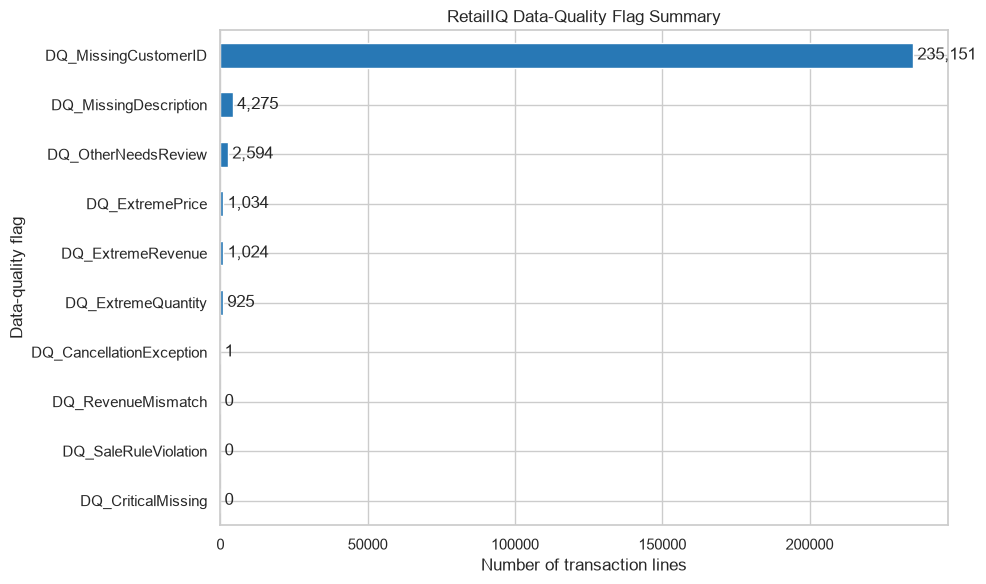

In [297]:
dq_columns = [
    column
    for column in clean_df.columns
    if column.startswith("DQ_")
]

data_quality_summary = (
    clean_df[dq_columns]
    .fillna(False)
    .astype(bool)
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

data_quality_summary.plot(
    kind="barh",
    ax=ax,
    color="#2878B5"
)

ax.set_title("RetailIQ Data-Quality Flag Summary")
ax.set_xlabel("Number of transaction lines")
ax.set_ylabel("Data-quality flag")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{int(value):,}"
            for value in data_quality_summary
        ],
        padding=3
    )

plt.tight_layout()

plt.savefig(
    figures_folder / "data_quality_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
figure_path = (
    figures_folder /
    "data_quality_summary.png"
)

print("Figure saved:", figure_path.exists())
print("Figure path:", figure_path)

Figure saved: True
Figure path: c:\Github\retail-financial-intelligence\reports\figures\data_quality_summary.png


: 